In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Caso 1. HORAS DE VIDEOCONFERENCIA

In [4]:
df = pd.read_csv("videoconferencia.csv")

In [5]:
df.head()

,Semana,Día,Horas
0,Semana 01,Lunes,1873263
1,Semana 01,Martes,908249
2,Semana 01,Miércoles,1717158
3,Semana 01,Jueves,1873263
4,Semana 01,Viernes,908249


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Semana  84 non-null     object
 1   Día     84 non-null     object
 2   Horas   84 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 2.1+ KB


In [7]:
df.describe()

,Horas
count,8.400000e+01
mean,3.933516e+06
std,2.533182e+06
min,6.811860e+05
25%,1.983956e+06
50%,3.090885e+06
75%,5.257060e+06
max,1.288806e+07


In [8]:
df.shape

(84, 3)

In [9]:
df_agrupado = ( df.groupby(["Día", "Semana"], observed=False)["Horas"] .sum() .reset_index())

In [10]:
tabla_calor = df_agrupado.pivot( index="Día", columns="Semana", values="Horas")


In [11]:
orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes"]

tabla_calor = tabla_calor.reindex(orden_dias)

Generar visualización con la personalización indicada y paleta Secuencial, color: YlGnBu

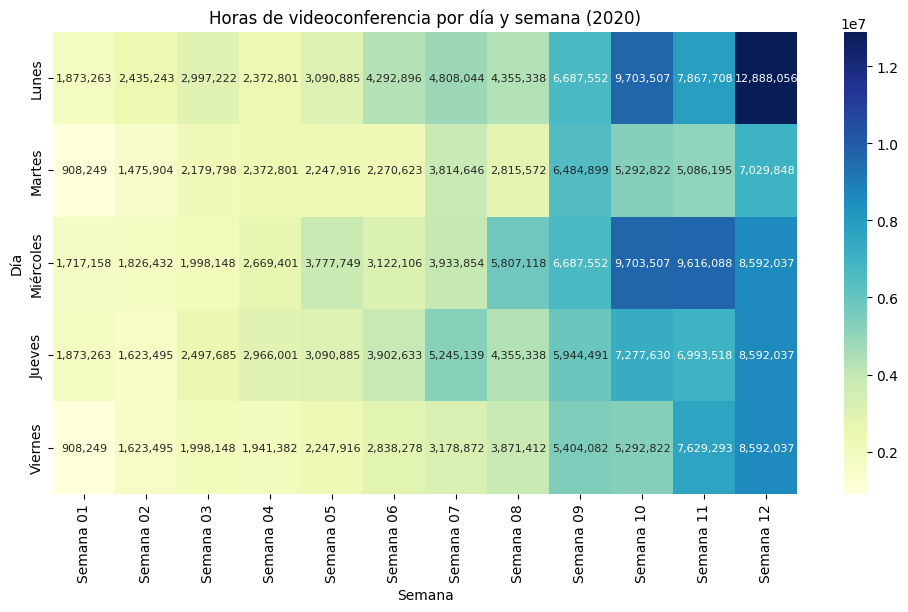

In [12]:
plt.figure(figsize=(12, 6))

sns.heatmap(tabla_calor, annot=True, fmt=",", cmap="YlGnBu", annot_kws={"size": 8})

plt.title("Horas de videoconferencia por día y semana (2020)")
plt.xlabel("Semana")
plt.ylabel("Día")
plt.show()

Para facilitar la interpretación se reescalaron las horas

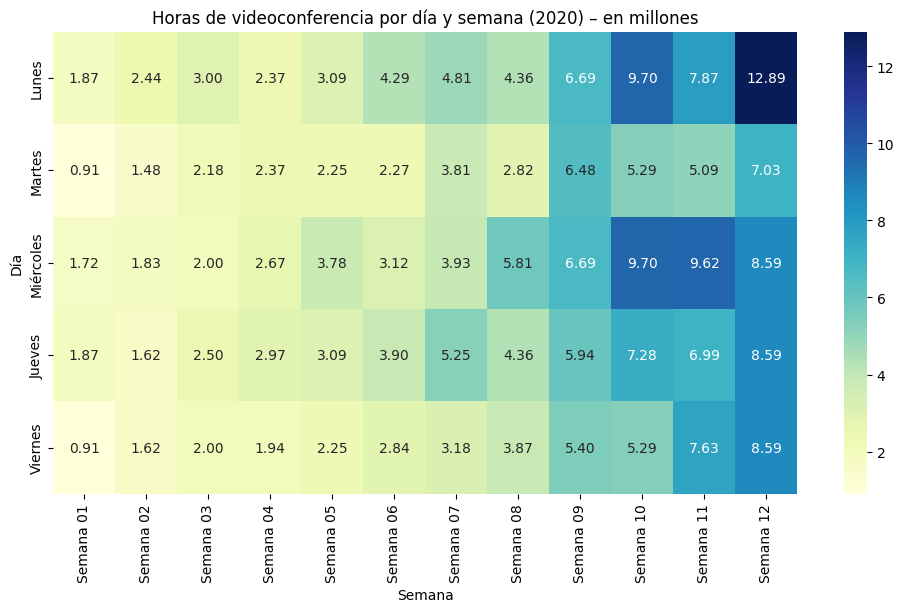

In [13]:
plt.figure(figsize=(12, 6))

sns.heatmap( tabla_calor / 1_000_000, annot=True, fmt=".2f", cmap="YlGnBu")

plt.title("Horas de videoconferencia por día y semana (2020) – en millones")
plt.xlabel("Semana")
plt.ylabel("Día")
plt.show()

Generar visualización con la personalización indicada y paleta Divergente, color: managua

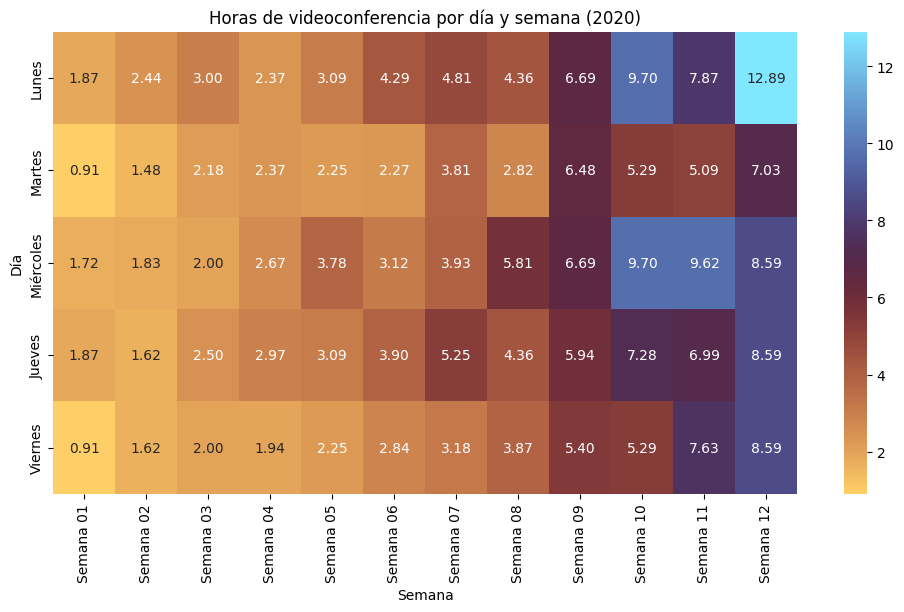

In [14]:
plt.figure(figsize=(12, 6))

sns.heatmap( tabla_calor / 1_000_000, annot=True, fmt=".2f", cmap="managua")

plt.title("Horas de videoconferencia por día y semana (2020)")
plt.xlabel("Semana")
plt.ylabel("Día")
plt.show()

¿Cuál paleta es la más efectiva para codificar los datos?

Para este caso, ambas paletas facilitan la interpretacón a simple vista. Sin embargo la paleta "Secuencial" resulta más efectiva para codificar los datos, debido a que el degradado progresivo del color deja identificar con mayor claridad el aumento de las horas de videoconferencia a lo largo de las semanas, muy marcado en la "semana 09", y entre los distintos días. Con la paleta divergente es necesario visualizar por unos segundos, más atentamente, para comprender como se distribuyen las semanas y días con mayor conexion de videoconferencias.

Caso 2. HUNDIMIENTO DEL TITANIC

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
df_titanic = sns.load_dataset("titanic")

In [16]:
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [17]:
df_titanic.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [18]:
df_titanic.info

<bound method DataFrame.info of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_m

In [19]:
df_titanic.shape

(891, 15)

In [20]:
df_titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [21]:
clases = df_titanic.groupby("class", observed=False).size()

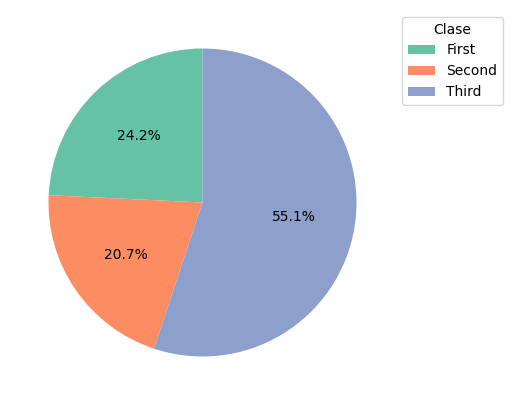

In [38]:
fig, chart = plt.subplots(1, 1, figsize=(5, 5))

chart.pie(clases, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("Set2"))
chart.legend( clases.index, title="Clase", bbox_to_anchor=(1, 1))
plt.show()

Se realiza cambio de color a la paleta "Paired" donde tambien se puede identificar la proporción por cada clase

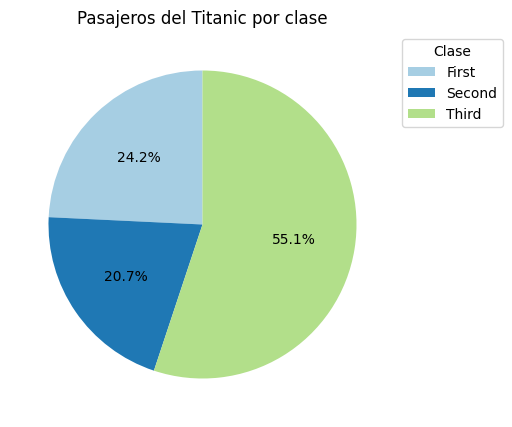

In [23]:
fig, chart = plt.subplots(1, 1, figsize=(5, 5))

chart.pie( clases, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("Paired"))
chart.legend(clases.index, title="Clase", bbox_to_anchor=(1, 1))
chart.set_title("Pasajeros del Titanic por clase")
plt.show()

In [24]:
no_sobrevivientes = df_titanic[df_titanic["survived"] == 0]
sobrevivientes = df_titanic[df_titanic["survived"] == 1]

In [25]:
clases_no = no_sobrevivientes.groupby("class", observed=False).size()
clases_si = sobrevivientes.groupby("class", observed=False).size()


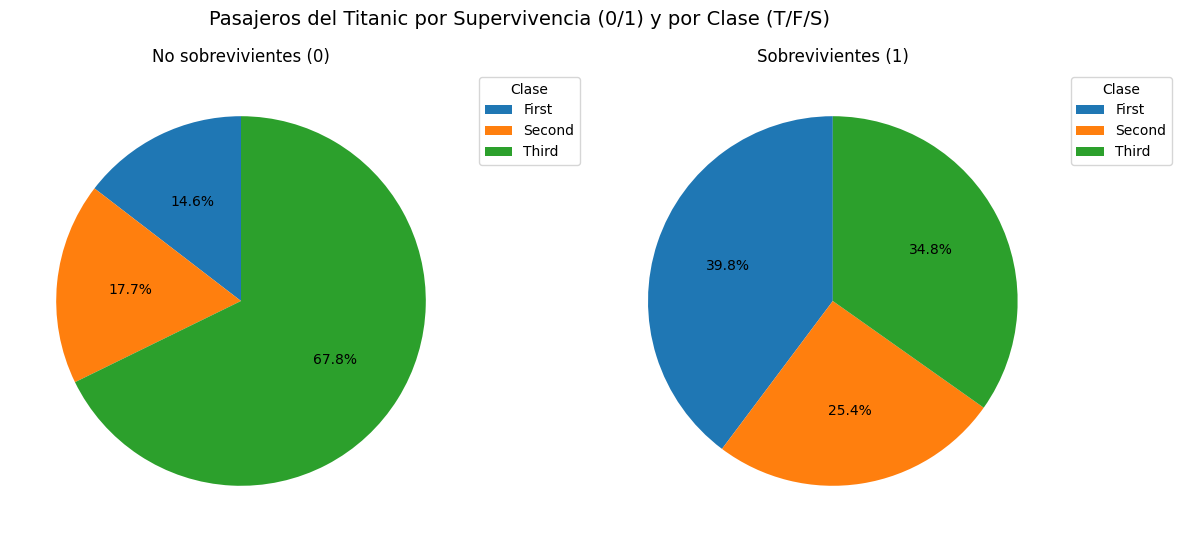

In [37]:
fig, charts = plt.subplots(1, 2, figsize=(14, 6))
charts[0].pie(clases_no, autopct="%1.1f%%", startangle=90)
charts[0].legend(clases_no.index, title="Clase", bbox_to_anchor=(1, 1))
charts[0].set_title("No sobrevivientes (0)")


charts[1].pie(clases_si, autopct="%1.1f%%", startangle=90)
charts[1].legend(clases_si.index, title="Clase", bbox_to_anchor=(1, 1))
charts[1].set_title("Sobrevivientes (1)")

plt.suptitle(
    "Pasajeros del Titanic por Supervivencia (0/1) y por Clase (T/F/S)",
    fontsize=14)
plt.show()

a) Sobre los supervivientes, ¿cuál es la clase de pasajero más común? La primera clase fue la más común, con un 39.8%.

b) De los no supervivientes ¿cuál es la clase de pasajero más común? En este ítem la clase de pasajero más común fue la tercera clase, con un 67.8%, esto se puede identificar claramente porque la proporción de la tercera clase tiene un ángulo mayor.

c) Aplicando los contenidos del curso y abstrayéndose de este caso en particular, ¿el grafico de torta es más efectivo que un gráfico de barras para comparar múltiples categorías? Considere 6 o más categorías distintas cuando indicamos “múltiples categorías”.

El gráfico de barras es más efectivo para visualizar multiples categorías, debido a que a simple vista se puede hacer una comparación directa entre ellas, mientras que en el gráfico de torta 6 o más categorias requieren de mas atención al detalle para identificar cada ángulo  y comparar su dimensión entre categorias.

Caso 3. PELICULAS

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df_peliculas = pd.read_csv("peliculas.csv")

In [29]:
df_peliculas.head()

,género,año,cantidad
0,acción,2010,11
1,acción,2011,14
2,acción,2012,22
3,acción,2013,11
4,acción,2014,12


In [30]:
df_peliculas.info

<bound method DataFrame.info of            género   año  cantidad
0          acción  2010        11
1          acción  2011        14
2          acción  2012        22
3          acción  2013        11
4          acción  2014        12
..            ...   ...       ...
125  mundo mágico  2015        29
126  mundo mágico  2016        30
127  mundo mágico  2017        11
128  mundo mágico  2018        22
129  mundo mágico  2019        15

[130 rows x 3 columns]>

In [31]:
df_peliculas.dtypes

género      object
año          int64
cantidad     int64
dtype: object

Gráfico de línea

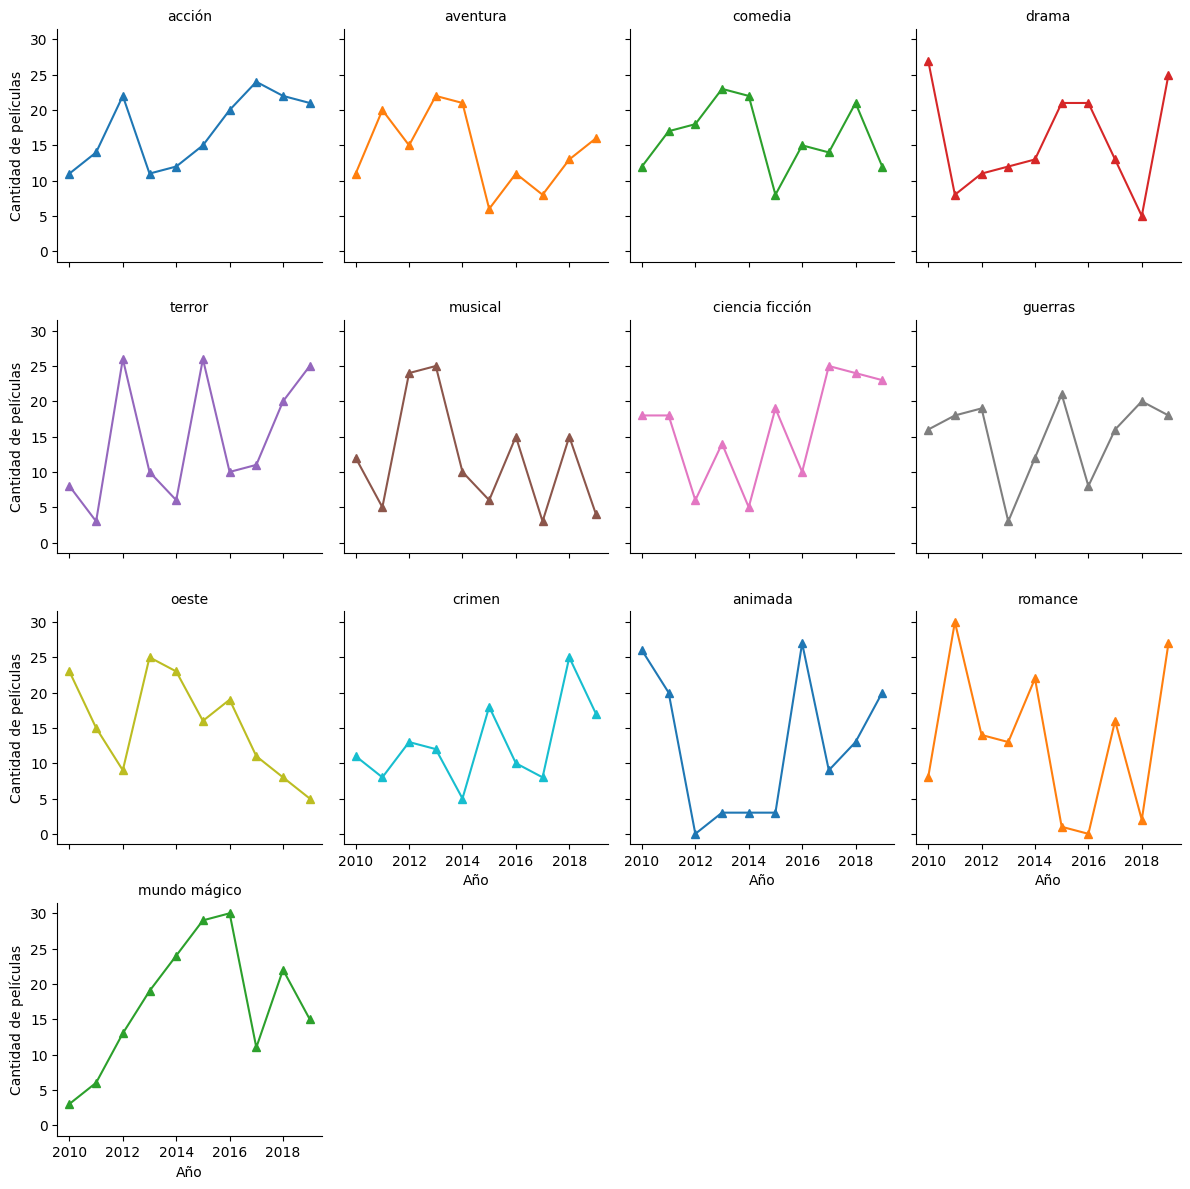

In [32]:
grid = sns.FacetGrid(data=df_peliculas, col="género", col_wrap=4, hue="género", palette="tab10")
grid.map(plt.plot, "año", "cantidad", marker="^")

grid.set_axis_labels("Año", "Cantidad de películas")
grid.set_titles(col_template="{col_name}")
plt.show()


Segundo Small Multiple: Gráfico de barra horizontal

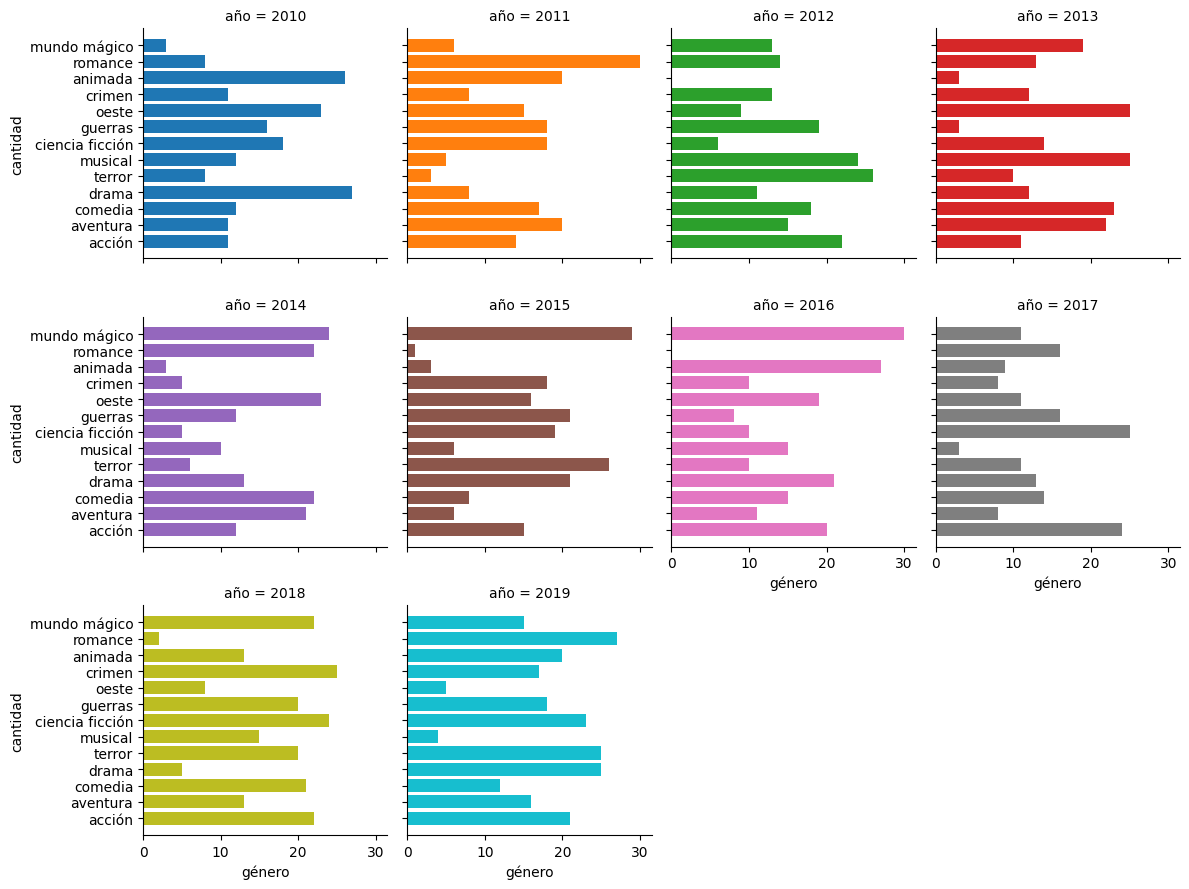

In [36]:
grid_barrahorizontal= sns.FacetGrid(data=df_peliculas, col="año", col_wrap=4, hue="año", palette="tab10")
grid_barrahorizontal.map(plt.barh, "género", "cantidad")



¿Cuál de las dos visualizaciones permite identificar eficazmente el género de películas más estrenados en 1 año específico? 

El gráfico de barras horizontales, porque los años se muestran por separado, además de que la longitud de la barra hace más fácil la identificación del género más estrenado, el cuál fue variando por año.

¿Cuál de las dos visualizaciones permite comparar eficazmente la tendencia de un género en particular entre los diferentes años? 

Un gráfico de líneas siempre va a mostrar mejor la tendencia, porque se puede visualizar el comportamiento de cada genero en una línea de tiempo, en este ejercicio, el género que se mantuvo más en tendencia fue: acción.